# RQ5: How do audio features vary across different popularity levels?

Dataset: Almost Million Songs Dataset (Kaggle)  
Target: Popularity  
Task: Trend Analysis using Popularity Groups

In [1]:
# ── Imports ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded ")

Libraries loaded 


In [2]:
# ── Load dataset ─────────────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            break

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing ─────────────────────────

TARGET = 'popularity'

drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.select_dtypes(include=[np.number])

df = df.dropna(subset=[TARGET])
df = df.fillna(df.median())

# reduce size (for speed)
if len(df) > 100000:
    df = df.sample(100000, random_state=42).reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (100000, 12)


In [4]:
# ── Create Popularity Groups ─────────────────────────

df['pop_group'] = pd.qcut(
    df['popularity'],
    q=4,
    duplicates='drop'
)

display(df[['popularity', 'pop_group']].head())

,popularity,pop_group
0,1.0,"(-0.001, 20.0]"
1,43.0,"(37.0, 93.0]"
2,0.0,"(-0.001, 20.0]"
3,63.0,"(37.0, 93.0]"
4,51.0,"(37.0, 93.0]"


In [5]:
# ── Aggregate Features ─────────────────────────

features_to_analyze = ['energy', 'danceability', 'acousticness', 'valence']

available_features = [f for f in features_to_analyze if f in df.columns]

trend_df = df.groupby('pop_group')[available_features].mean().reset_index()

# 🔥 FIX: convert Interval → string
trend_df['pop_group'] = trend_df['pop_group'].astype(str)

display(trend_df)

,pop_group,energy,danceability,acousticness,valence
0,"(-0.001, 20.0]",0.506238,0.533316,0.455753,0.427125
1,"(20.0, 37.0]",0.538284,0.547283,0.409977,0.426707
2,"(37.0, 93.0]",0.589611,0.586725,0.341297,0.468691


In [6]:
# ── Table 5.1 ─────────────────────────

styled = trend_df.style\
    .format({
        col: "{:.3f}" for col in trend_df.columns if col != 'pop_group'
    })\
    .set_caption("Table 5.1: Audio Features across Popularity Levels (RQ5)")\
    .background_gradient(cmap="coolwarm", subset=[
        col for col in trend_df.columns if col != 'pop_group'
    ])\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })

display(styled)

,pop_group,energy,danceability,acousticness,valence
0,"(-0.001, 20.0]",0.506,0.533,0.456,0.427
1,"(20.0, 37.0]",0.538,0.547,0.410,0.427
2,"(37.0, 93.0]",0.590,0.587,0.341,0.469


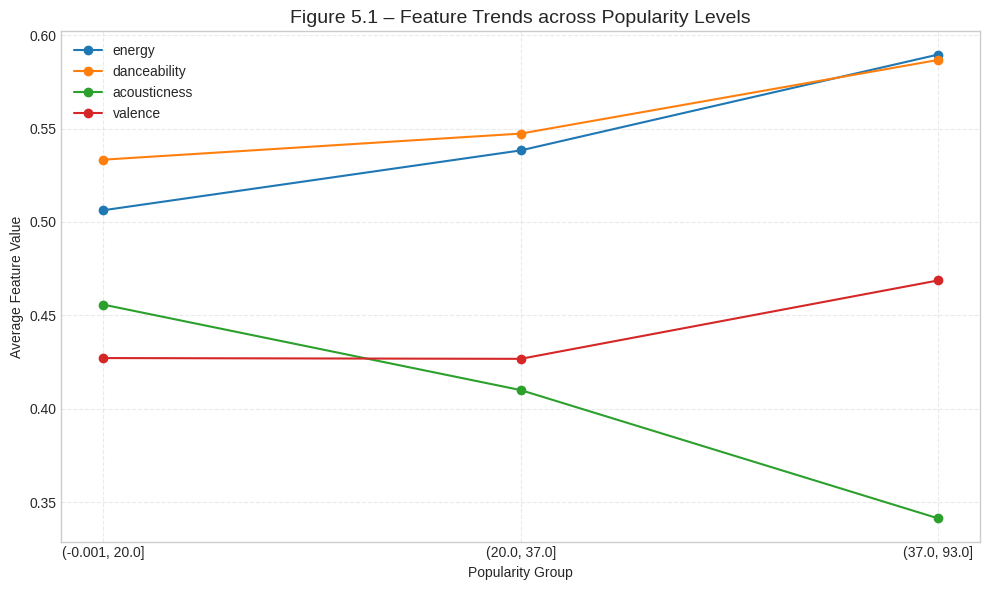

In [7]:
# ── Figure 5.1 ─────────────────────────

plt.figure(figsize=(10,6))

for col in available_features:
    plt.plot(trend_df['pop_group'], trend_df[col], marker='o', label=col)

plt.title("Figure 5.1 – Feature Trends across Popularity Levels", fontsize=14)
plt.xlabel("Popularity Group")
plt.ylabel("Average Feature Value")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

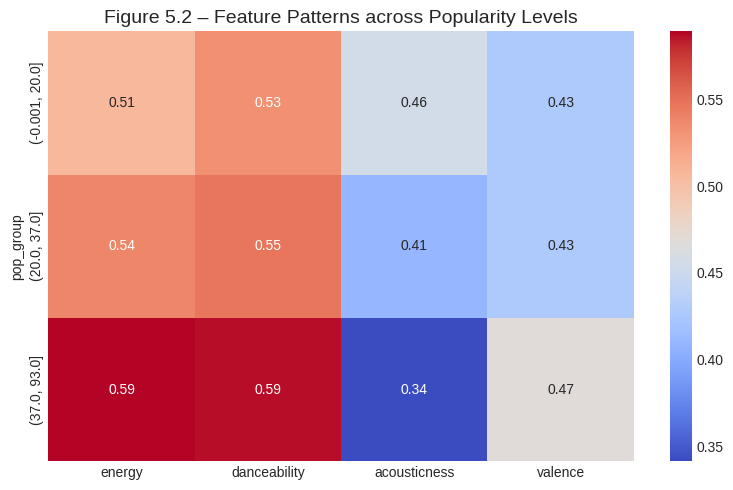

In [8]:
# ── Figure 5.2 ─────────────────────────

plt.figure(figsize=(8,5))

sns.heatmap(
    trend_df.set_index('pop_group'),
    cmap="coolwarm",
    annot=True
)

plt.title("Figure 5.2 – Feature Patterns across Popularity Levels", fontsize=14)

plt.tight_layout()
plt.show()

In [9]:
# ── Conclusion ─────────────────────────

print("Conclusion:")
print("Audio features vary across different popularity levels.")
print("Highly popular songs show distinct patterns in energy, danceability, and acousticness.")

Conclusion:
Audio features vary across different popularity levels.
Highly popular songs show distinct patterns in energy, danceability, and acousticness.
